# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import plotly.express as px

In [3]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(15)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB
None


In [5]:
df['Income'] = df['Income'].str.replace('.', '',regex=False).str.replace(',', '.', regex=False).astype(float)

print(df['Income'].head())

0     50000.0
1    100000.0
2     75000.0
3    125000.0
4    100000.0
Name: Income, dtype: float64


In [6]:
print(df['Credit Score'].unique())

['High' 'Average' 'Low']


In [7]:
mapa = {'Low': 1, 'Average': 2, 'High': 3}

df['Credit Score'] = df['Credit Score'].map(mapa).astype(float)

print(df['Credit Score'].unique())

[3. 2. 1.]


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [8]:
# Mediana
mediana_idade = df['Age'].median()

# Removendo os nulos
df['Age'] = df['Age'].fillna(mediana_idade)

# Convertendo valores para inteiros
df['Age'] = df['Age'].astype(int)

print(df['Age'].unique())

[25 30 35 40 45 50 26 31 36 43 48 53 29 34 39 44 49 41 46 51 27 32 37 42
 47 52 28 33 38]


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [9]:
colunas_categoricas = ['Gender', 'Marital Status', 'Home Ownership', 'Education']

for col in colunas_categoricas:
    print(f"Valores únicos em {col}:")
    print(df[col].unique())
    print("-" * 30)# Separação "pontilhada" entre as analises

Valores únicos em Gender:
['Female' 'Male']
------------------------------
Valores únicos em Marital Status:
['Single' 'Married']
------------------------------
Valores únicos em Home Ownership:
['Rented' 'Owned']
------------------------------
Valores únicos em Education:
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
------------------------------


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [10]:
print(df.describe())

              Age         Income  Number of Children  Credit Score
count  164.000000     164.000000          164.000000    164.000000
mean    37.195122   83765.243902            0.652439      2.597561
std      7.586619   32457.306728            0.883346      0.652692
min     25.000000   25000.000000            0.000000      1.000000
25%     31.750000   57500.000000            0.000000      2.000000
50%     36.000000   83750.000000            0.000000      3.000000
75%     43.000000  105000.000000            1.000000      3.000000
max     53.000000  162500.000000            3.000000      3.000000


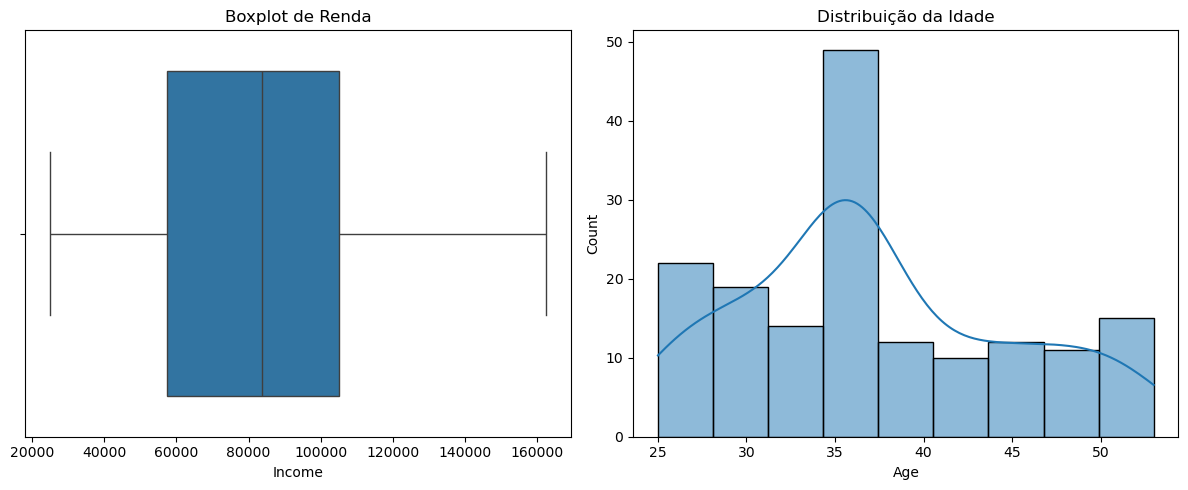

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Income'])
plt.title('Boxplot de Renda')



plt.subplot(1, 2, 2)
sns.histplot(df['Age'], kde=True)
plt.title('Distribuição da Idade')
plt.tight_layout()
plt.show()

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

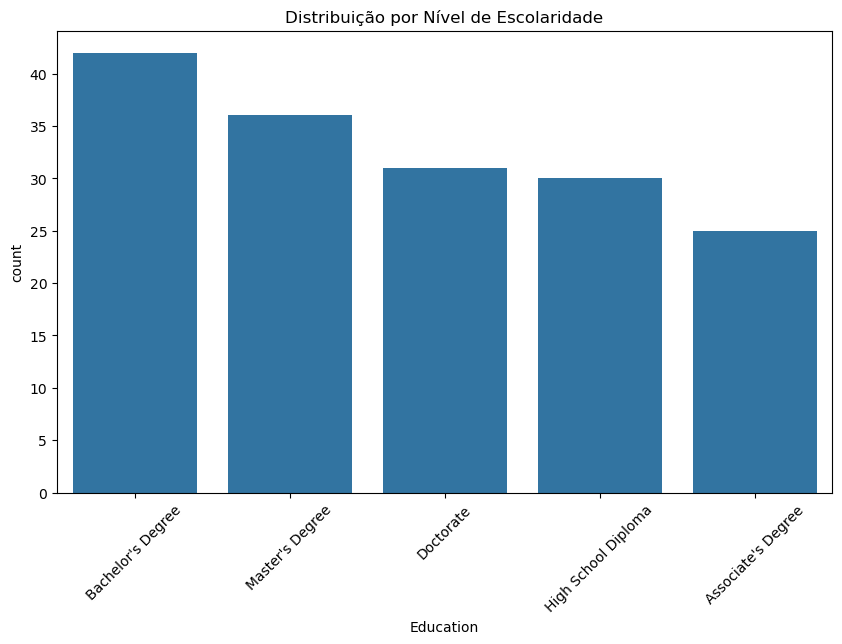

In [12]:
#seu código aqui
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribuição por Nível de Escolaridade')
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [13]:
# Não identifiquei nenhum outlier na base de dados.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



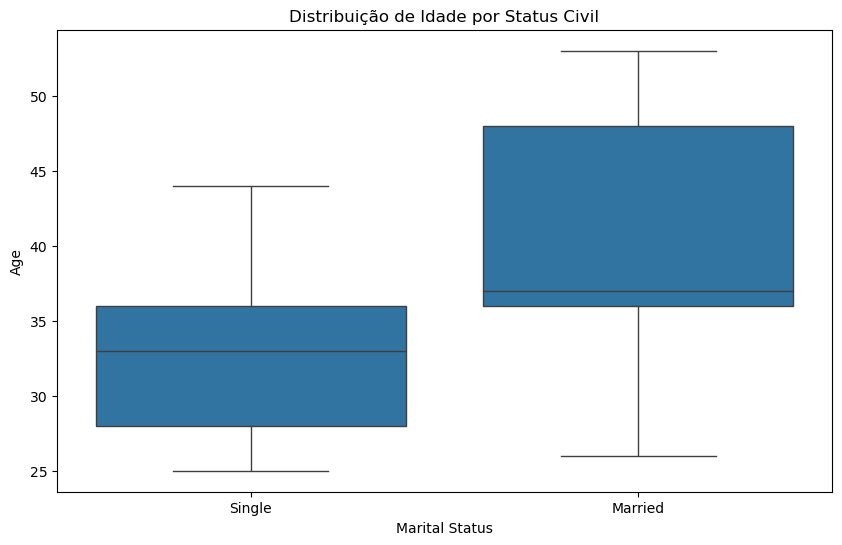

In [14]:
# Existe relação entre a idade e o status civil?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Marital Status', y='Age')
plt.title('Distribuição de Idade por Status Civil')
plt.show()

In [15]:
# Claramente a taxa de pessoas casadas aumenta a partir dos 35 anos.

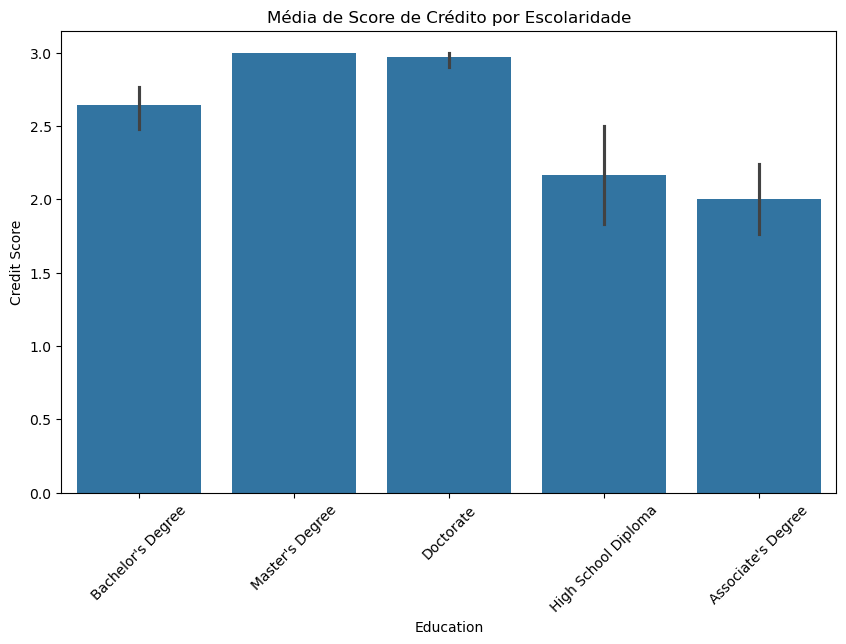

In [16]:
# Qual a relação entre o score de crédito e o nível de escolaridade?
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Education', y='Credit Score')
plt.xticks(rotation=45)
plt.title('Média de Score de Crédito por Escolaridade')
plt.show()

In [17]:
# Os niveis de escolaridade mais altos como doltorado e mestrado tem uma taxa media de score maior.

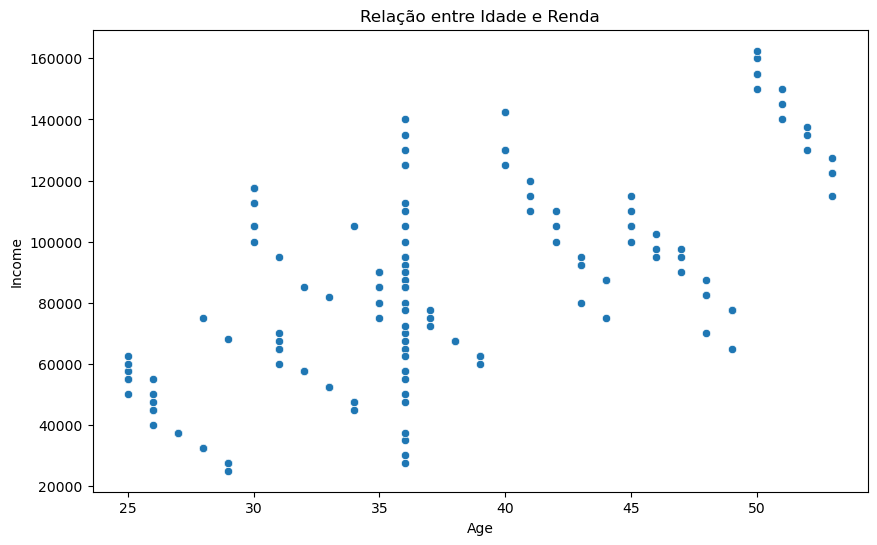

In [18]:
# O salário parece influenciar na idade?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Income')
plt.title('Relação entre Idade e Renda')
plt.show()

In [19]:
# As pessoas mais velhas geralmente recebem mais.

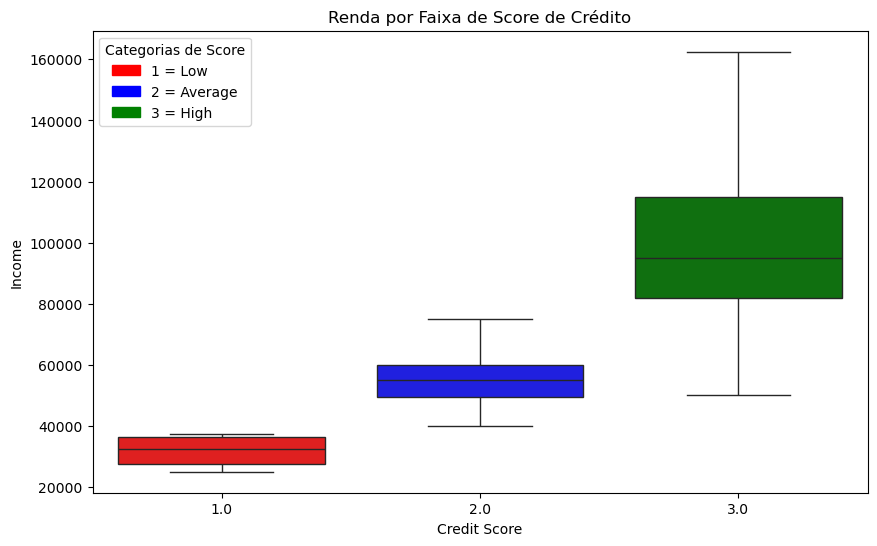

In [20]:
# O salário parece influenciar no Score de Crédito?
plt.figure(figsize=(10, 6))


sns.boxplot(data=df, x='Credit Score', y='Income', hue='Credit Score', 
            palette=['red', 'blue', 'green'], legend=False)

low_patch = mpatches.Patch(color='red', label='1 = Low')
avg_patch = mpatches.Patch(color='blue', label='2 = Average')
high_patch = mpatches.Patch(color='green', label='3 = High')

plt.legend(handles=[low_patch, avg_patch, high_patch], title="Categorias de Score", loc='upper left')
plt.title('Renda por Faixa de Score de Crédito')
plt.show()

In [21]:
# Os maiores salários tem maior score, o que me leva a crer que as pessoas mais velhas tem um score maior baseado na analise anterior.

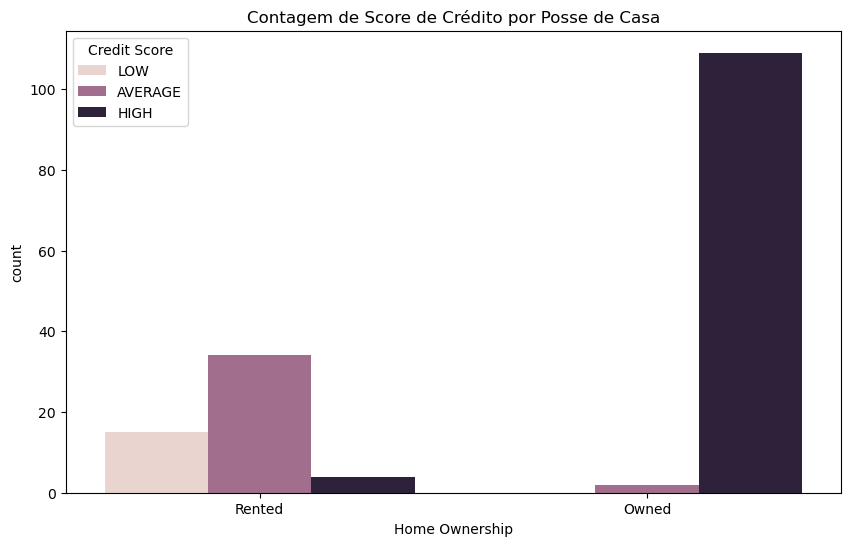

In [22]:
# Clientes com casa própria tendem a ter um score mais alto?
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Home Ownership', hue='Credit Score')

# Legenda
plt.legend(title='Credit Score', labels=['LOW', 'AVERAGE', 'HIGH'])

plt.title('Contagem de Score de Crédito por Posse de Casa')
plt.show()

In [23]:
# Quem tem casa propria tem uma consentração de score muito maior em comparação a quem vive de aluguel.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

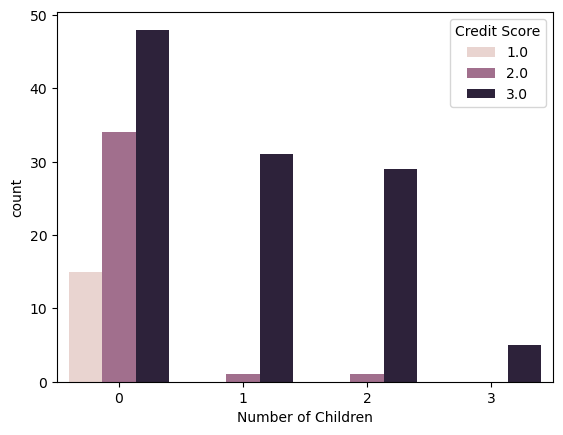

In [26]:
# A quantidade de filhos influencia no Score de Crédito?
sns.countplot(data=df, x='Number of Children', hue='Credit Score')
plt.show()

In [ ]:
# O número de filhos influencia o crédito, possoivelmente influencido pelo gerenciamento de um lar com mais filhos.

([0, 1, 2, 3, 4],
 [Text(0, 0, "Bachelor's Degree"),
  Text(1, 0, "Master's Degree"),
  Text(2, 0, 'Doctorate'),
  Text(3, 0, 'High School Diploma'),
  Text(4, 0, "Associate's Degree")])

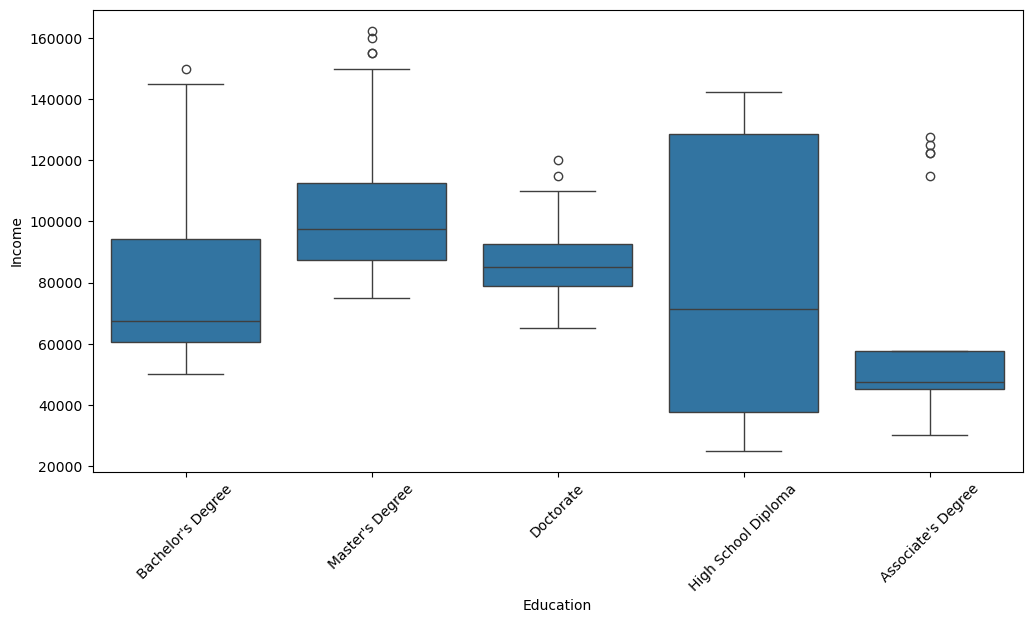

In [28]:
# Qual a distribuição de renda por Nível de Escolaridade?
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)

C:\Users\vagne\AppData\Local\Temp\ipykernel_12576\2317421686.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y='Income', data=df, inner='quartile', palette='muted')


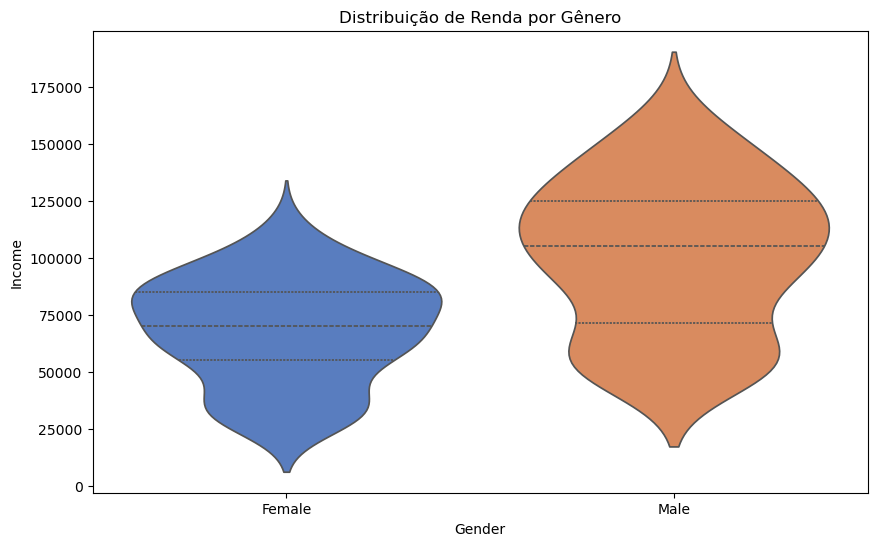

In [29]:
# Existe disparidade de renda entre gêneros nessa base?
plt.figure(figsize=(10, 6))

sns.violinplot(x='Gender', y='Income', data=df, inner='quartile', palette='muted')
plt.title('Distribuição de Renda por Gênero')
plt.show()

In [ ]:
# R: Vemos aqui uma distribuição maior de renda para homens na parte superior, indicando uma disparidade salárial alta.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

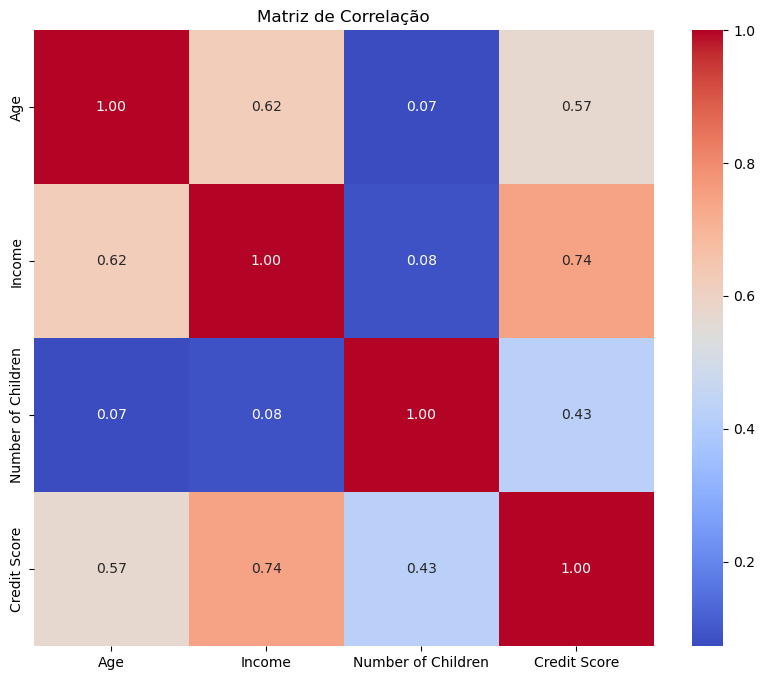

In [25]:
#Matriz de correlação para colunas númericas
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [ ]:
# R: O número de crianças parece estar altamente relacionado a idade e a renda, e a renda visivelmente influencia bastante no credito.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [30]:
colunas_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership']

df_processado = pd.get_dummies(df, columns=colunas_categoricas)

df_processado.head()

,Age,Income,Number of Children,Credit Score,Gender_Female,Gender_Male,Education_Associate's Degree,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,50000.0,0,3.0,True,False,False,True,False,False,False,False,True,False,True
1,30,100000.0,2,3.0,False,True,False,False,False,False,True,True,False,True,False
2,35,75000.0,1,3.0,True,False,False,False,True,False,False,True,False,True,False
3,40,125000.0,0,3.0,False,True,False,False,False,True,False,False,True,True,False
4,45,100000.0,3,3.0,True,False,False,True,False,False,False,True,False,True,False


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

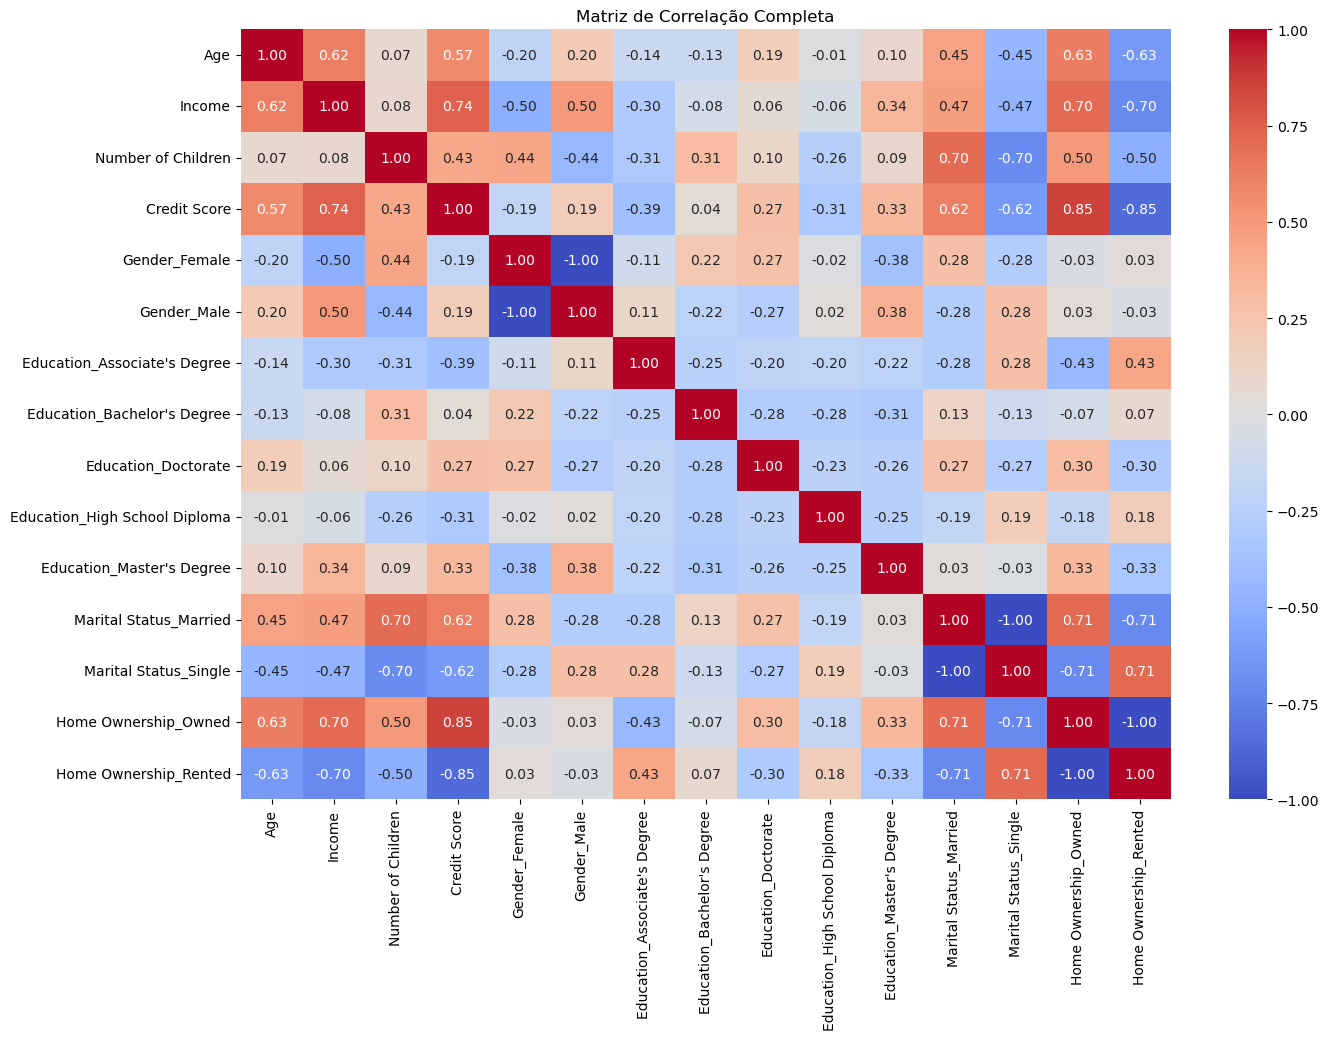

In [32]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_processado.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação Completa')
plt.show()

In [ ]:
# R: Agora podemos ver novas variáveis com grande correlação compo o fato de ter uma casa alugada ou própria serem relacionadas perfeitamente em oposto
# com o score de crédito. As pessoas mais velhas e com maior renda tendem a ter casa própria.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [33]:
from sklearn.model_selection import train_test_split

X = df_processado.drop('Credit Score', axis=1)
y = df_processado['Credit Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")

Shape de X_train: (131, 14)
Shape de X_test: (33, 14)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

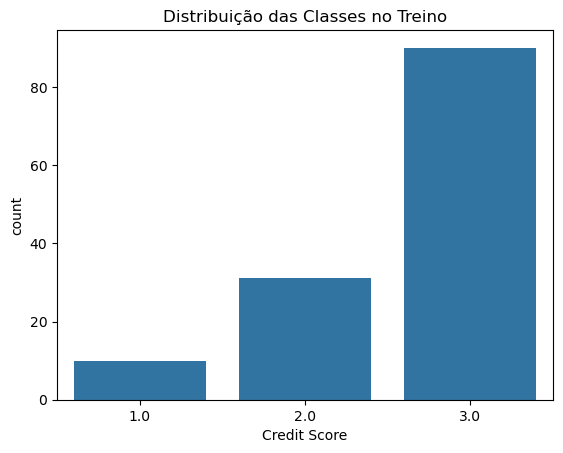

In [34]:
sns.countplot(x=y_train)
plt.title('Distribuição das Classes no Treino')
plt.show()

In [ ]:
# A margem de baixo crédito tem poucos dados, será nescessário aplicar um smote para balancear.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

Antes do SMOTE: Credit Score
3.0    90
2.0    31
1.0    10
Name: count, dtype: int64
Depois do SMOTE: Credit Score
3.0    90
2.0    90
1.0    90
Name: count, dtype: int64


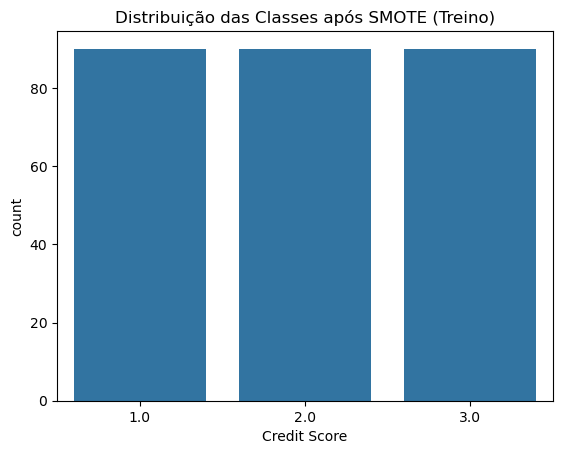

In [37]:
from imblearn.over_sampling import SMOTE

# Criando a nova base de treino balanceada
X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts()}")
print(f"Depois do SMOTE: {y_train_res.value_counts()}")

# Plotando para confirmar
sns.countplot(x=y_train_res)
plt.title('Distribuição das Classes após SMOTE (Treino)')
plt.show()